# 24/05/2026 ML Pipeline for EEG data classification on the Kuo & Prat (2023) data set.
# **CROSS-SUBJECT/INTER-SUBJECT LEVEL CLASSIFICATION**

ML MODELS:
*   Linear Discriminant Analysis (LDA) - Ledoit Wolf
*   Suuport Vector Machine (SVM) - linear/radial
*   Random Forest (RF)
* Multilayer Perceptron (MLP)

## 1. Environment + Data Loading

Step 1.1: Global imports and Google Drive mounting.

Step 1.2: Metadata filtering and .set file loading via MNE.

Step 1.3: Feature Extraction (isolating the 500-800ms P600 ROI, extracting 2D matrices).

In [1]:
!pip install -q mne scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 114.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import mne

from google.colab import drive

warnings.filterwarnings('ignore')

# scikit learn imports
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    LeaveOneGroupOut,
    cross_val_predict,
    permutation_test_score,
    GridSearchCV
)
from sklearn.metrics import confusion_matrix

# MODEL IMPORTS
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [3]:
if not os.path.exists('/content/drive/MyDrive'):
    print("Mounting Google Drive.")
    drive.mount('/content/drive', force_remount=True)
else:
    print("Google Drive is already actively mounted.")
# dirs
BASE_DIR = "/content/drive/MyDrive/EEG_data/full_subject_list"
EPOCHS_DIR = BASE_DIR
METADATA_PATH = os.path.join(BASE_DIR, "participants.tsv")

print("--- ENVIRONMENT LOADED ---")
print(f"Base Directory: {BASE_DIR}")
print(f"MNE Version: {mne.__version__}")

Mounting Google Drive.
Mounted at /content/drive
--- ENVIRONMENT LOADED ---
Base Directory: /content/drive/MyDrive/EEG_data/full_subject_list
MNE Version: 1.12.1


In [4]:
print("\n--- PROCESSING METADATA ---")
try:
    meta_df = pd.read_csv(METADATA_PATH, sep='\t')

    # filtering from participants tsv for usable data
    if 'data_usability' in meta_df.columns:
        valid_meta_df = meta_df[meta_df['data_usability'] == 'good'].copy()
        print(f"Filtered out {len(meta_df) - len(valid_meta_df)} unusable subjects.")
    else:
        valid_meta_df = meta_df.copy()
        print("Warning: 'data_usability' not found. Proceeding with all subjects.")

    print(f"Usable subjects retained: {valid_meta_df.shape[0]}")
    print(f"Group distribution:\n{valid_meta_df['python_expertise'].value_counts()}\n")

    # MAPPING TO EXPERTISE LEVEL
    expertise_map = dict(zip(valid_meta_df['participant_id'], valid_meta_df['python_expertise']))

except Exception as e:
    print(f"Metadata Initialization Error: {e}")


--- PROCESSING METADATA ---
Filtered out 16 unusable subjects.
Usable subjects retained: 45
Group distribution:
python_expertise
Expert    27
Novice    18
Name: count, dtype: int64



### 1.2 Data Loading + Feature Extraction

agreggating the 2D matrices for the cross-subject pipeline + EOI for the P600 (electrode channels and temporal averaging)

In [5]:
# GLOBAL DATA EXTRACTION & FEATURE ENGINEERING

print("\n--- DATA LOADING + FEATURE EXTRACTION ---")

# lists for agreggation
X_list = []
y_list = []
groups_list = []
expertise_list = []

# P600 spatial and temporal ROI
p600_roi = ['Fz', 'Cz', 'Pz', 'FC1', 'FC2', 'CP1', 'CP2']
tmin_roi, tmax_roi = 0.5, 0.8

for sub_id in valid_meta_df['participant_id']:
    search_pattern = os.path.join(EPOCHS_DIR, sub_id, '**', '*.set')
    set_files = glob.glob(search_pattern, recursive=True)

    if not set_files:
        continue

    set_file_path = set_files[0]
    expertise = expertise_map.get(sub_id, "Unknown")

    try:
        # LOADING EPOCHS FROM EEGLAB
        epochs = mne.io.read_epochs_eeglab(set_file_path, verbose=False)

        # mapping triggers
        valid_codes = [code for label, code in epochs.event_id.items() if '110' in label or '115' in label]
        invalid_codes = [code for label, code in epochs.event_id.items() if '220' in label or '225' in label]

        if not valid_codes or not invalid_codes:
            continue

        # filtering the events
        combined_codes = valid_codes + invalid_codes
        epochs_filtered = epochs[np.isin(epochs.events[:, 2], combined_codes)]

        # target vector Y
        filtered_events = epochs_filtered.events[:, 2]
        y_sub = np.array([0 if ev in valid_codes else 1 for ev in filtered_events])

        # FEATURE EXTRACTION -> ROI for the P600
        epochs_roi = epochs_filtered.copy().pick(p600_roi).crop(tmin=tmin_roi, tmax=tmax_roi)

        # temporal averaging from 3D to 2D matrices
        X_3d = epochs_roi.get_data()
        X_2d_sub = np.mean(X_3d, axis=2)

        # group/expertise vectors
        groups_sub = np.array([sub_id] * len(y_sub))
        expertise_sub = np.array([expertise] * len(y_sub))

        # appending
        X_list.append(X_2d_sub)
        y_list.append(y_sub)
        groups_list.append(groups_sub)
        expertise_list.append(expertise_sub)

    except Exception as e:
        print(f"Error processing {sub_id}: {e}")

X_global = np.vstack(X_list)
y_global = np.concatenate(y_list)
groups_global = np.concatenate(groups_list)
expertise_global = np.concatenate(expertise_list)

print("--- GLOBAL EXTRACTION COMPLETE ---")
print(f"X_global shape:       {X_global.shape} (Total Epochs, Channels)")
print(f"y_global shape:       {y_global.shape}")
print(f"groups_global shape:  {groups_global.shape}")
print(f"expertise_global:     {expertise_global.shape}")
print(f"Unique Subjects:      {len(np.unique(groups_global))}")


--- DATA LOADING + FEATURE EXTRACTION ---
--- GLOBAL EXTRACTION COMPLETE ---
X_global shape:       (3600, 7) (Total Epochs, Channels)
y_global shape:       (3600,)
groups_global shape:  (3600,)
expertise_global:     (3600,)
Unique Subjects:      45


## 2. Baseline Models Classification

Cross-Subject Classification (LOGO-CV)
source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneGroupOut.html

In [6]:
# BALANCING THE GROUPS

print("\n--- BALANCING THE GROUPS ---")

np.random.seed(42)

# extracting the subs
unique_subjects = np.unique(groups_global)
novice_subjects = [sub for sub in unique_subjects if expertise_map.get(sub) == 'Novice']
expert_subjects = [sub for sub in unique_subjects if expertise_map.get(sub) == 'Expert']

print(f"Original Novice Count: {len(novice_subjects)}")
print(f"Original Expert Count: {len(expert_subjects)}")

# downsampling Experts to match Novices
N_target = len(novice_subjects)
expert_subjects_balanced = np.random.choice(expert_subjects, size=N_target, replace=False)

print(f"Balanced Expert Count: {len(expert_subjects_balanced)}")

novice_mask = np.isin(groups_global, novice_subjects)
expert_mask = np.isin(groups_global, expert_subjects_balanced)

# slicing into final metrics
X_novice = X_global[novice_mask]
y_novice = y_global[novice_mask]
groups_novice = groups_global[novice_mask]

X_expert = X_global[expert_mask]
y_expert = y_global[expert_mask]
groups_expert = groups_global[expert_mask]

print("\n--- BALANCED MATRICES SUMMARY ---")
print(f"Novice Matrix - X: {X_novice.shape}, y: {y_novice.shape}")
print(f"Expert Matrix - X: {X_expert.shape}, y: {y_expert.shape}")


--- BALANCING THE GROUPS ---
Original Novice Count: 18
Original Expert Count: 27
Balanced Expert Count: 18

--- BALANCED MATRICES SUMMARY ---
Novice Matrix - X: (1440, 7), y: (1440,)
Expert Matrix - X: (1440, 7), y: (1440,)


In [7]:
# BASELINE ML CLASSIFICATION
from sklearn.model_selection import cross_val_score

print("\n--- BASELINE LOGO-CV CLASSIFICATION ---")

# ML pipelines
baseline_pipelines = {
    'LDA (Ledoit-Wolf)': make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    ),
    'SVM-Linear': make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', class_weight='balanced', max_iter=10000, random_state=42)
    ),
    'SVM-RBF': make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', class_weight='balanced', random_state=42)
    ),
    'Random Forest': make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    ),
    'MLP': make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, early_stopping=True, random_state=42)
    )
}

# strcuturing the cohorts for an evaluation
cohorts = {
    'Global (N=45)': (X_global, y_global, groups_global),
    'Novices (N=18)': (X_novice, y_novice, groups_novice),
    'Experts (N=18)': (X_expert, y_expert, groups_expert)
}

logo = LeaveOneGroupOut()
baseline_results = {}

for cohort_name, (X_data, y_data, groups_data) in cohorts.items():
    print(f"\nEvaluating Cohort: {cohort_name}")
    baseline_results[cohort_name] = {}

    for model_name, pipeline in baseline_pipelines.items():
        # LOGO-CV
        scores = cross_val_score(
            pipeline,
            X_data,
            y_data,
            cv=logo,
            groups=groups_data,
            n_jobs=-1
        )

        # calculating the metrics
        mean_acc = np.mean(scores)
        std_acc = np.std(scores)
        baseline_results[cohort_name][model_name] = {'mean': mean_acc, 'std': std_acc}

        print(f"  -> {model_name.ljust(18)} | Mean Acc: {mean_acc:.4f} ± {std_acc:.4f}")

print("\n--- BASELINE EVALUATION COMPLETE ---")


--- BASELINE LOGO-CV CLASSIFICATION ---

Evaluating Cohort: Global (N=45)
  -> LDA (Ledoit-Wolf)  | Mean Acc: 0.5650 ± 0.0688
  -> SVM-Linear         | Mean Acc: 0.5619 ± 0.0681
  -> SVM-RBF            | Mean Acc: 0.5575 ± 0.0730
  -> Random Forest      | Mean Acc: 0.5208 ± 0.0577
  -> MLP                | Mean Acc: 0.5481 ± 0.0642

Evaluating Cohort: Novices (N=18)
  -> LDA (Ledoit-Wolf)  | Mean Acc: 0.5271 ± 0.0493
  -> SVM-Linear         | Mean Acc: 0.5271 ± 0.0502
  -> SVM-RBF            | Mean Acc: 0.5153 ± 0.0511
  -> Random Forest      | Mean Acc: 0.4812 ± 0.0636
  -> MLP                | Mean Acc: 0.5299 ± 0.0701

Evaluating Cohort: Experts (N=18)
  -> LDA (Ledoit-Wolf)  | Mean Acc: 0.5715 ± 0.0684
  -> SVM-Linear         | Mean Acc: 0.5694 ± 0.0652
  -> SVM-RBF            | Mean Acc: 0.5722 ± 0.0619
  -> Random Forest      | Mean Acc: 0.5292 ± 0.0503
  -> MLP                | Mean Acc: 0.5542 ± 0.0608

--- BASELINE EVALUATION COMPLETE ---


## 3. Hyperparameter Tuning (Grid Search)

Performing a GridSearchCV tuning on all four models (LDA, SVM, RF, MLP). Optimizing over the StratifiedFFold to find the mathematically optimal configuration per model.

Source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html https://scikit-learn.org/stable/modules/grid_search.html



In [8]:
# HYPERPARAMETER TUNING
import time
from sklearn.model_selection import GridSearchCV
print("\n--- INITIATING HYPERPARAMETER TUNING (LOGO-CV) ---")
start_time = time.time()
# defining baseline
tuning_pipelines = {
    'LDA': make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr')),
    'SVM-Linear': make_pipeline(StandardScaler(), SVC(kernel='linear', class_weight='balanced', max_iter=10000, random_state=42)),
    'SVM-RBF': make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42)),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(class_weight='balanced', random_state=42)),
    'MLP': make_pipeline(StandardScaler(), MLPClassifier(solver='adam', max_iter=1000, early_stopping=True, random_state=42))
}

# defining the grid parameters
param_grids = {
    'LDA': {
        'lineardiscriminantanalysis__shrinkage': np.linspace(0.01, 0.99, 10)
    },
    'SVM-Linear': {
        'svc__C': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    'SVM-RBF': {
        'svc__C': [0.01, 0.1, 1.0, 10.0],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    },
    'Random Forest': {
        'randomforestclassifier__n_estimators': [50, 100, 200],
        'randomforestclassifier__max_depth': [3, 5, 7, None],
        'randomforestclassifier__min_samples_leaf': [1, 2, 4]
    },
    'MLP': {
        'mlpclassifier__hidden_layer_sizes': [(5,), (10,), (7, 3), (15, 5), (50, 25)],
        'mlpclassifier__alpha': [0.001, 0.01, 0.1, 1.0],
        'mlpclassifier__learning_rate_init': [0.001, 0.01]
    }
}

tuning_cohorts = {
    'Global': (X_global, y_global, groups_global),
    'Novices': (X_novice, y_novice, groups_novice),
    'Experts': (X_expert, y_expert, groups_expert)
}
# LEAVING ONE GROUP OUT
logo_grid = LeaveOneGroupOut()
best_estimators_dict = {'Global': {}, 'Novices': {}, 'Experts': {}}

for cohort, (X_data, y_data, groups_data) in tuning_cohorts.items():
    print(f"\n--- Optimizing Hyperparameters for {cohort} ---")

    for model_name, pipeline in tuning_pipelines.items():
        print(f"Running GridSearch for {model_name}...")

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            cv=logo_grid,
            scoring='accuracy',
            n_jobs=-1
        )

        # Fit GridSearch
        grid_search.fit(X_data, y_data, groups=groups_data)

        # storing the best estimator
        best_estimators_dict[cohort][model_name] = grid_search.best_estimator_

        best_acc = grid_search.best_score_
        clean_params = {k.split('__')[1]: v for k, v in grid_search.best_params_.items()}
        print(f"  -> {model_name.ljust(13)} Best Acc: {best_acc:.4f} | Optimal Params: {clean_params}")

elapsed_time = (time.time() - start_time) / 60
print(f"\n--- EXPANDED GRID SEARCH COMPLETE ({elapsed_time:.2f} minutes) ---")


--- INITIATING HYPERPARAMETER TUNING (LOGO-CV) ---

--- Optimizing Hyperparameters for Global ---
Running GridSearch for LDA...
  -> LDA           Best Acc: 0.5667 | Optimal Params: {'shrinkage': np.float64(0.44555555555555554)}
Running GridSearch for SVM-Linear...
  -> SVM-Linear    Best Acc: 0.5636 | Optimal Params: {'C': 0.001}
Running GridSearch for SVM-RBF...
  -> SVM-RBF       Best Acc: 0.5683 | Optimal Params: {'C': 0.01, 'gamma': 'scale'}
Running GridSearch for Random Forest...
  -> Random Forest Best Acc: 0.5650 | Optimal Params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 50}
Running GridSearch for MLP...
  -> MLP           Best Acc: 0.5661 | Optimal Params: {'alpha': 0.01, 'hidden_layer_sizes': (7, 3), 'learning_rate_init': 0.01}

--- Optimizing Hyperparameters for Novices ---
Running GridSearch for LDA...
  -> LDA           Best Acc: 0.5278 | Optimal Params: {'shrinkage': np.float64(0.01)}
Running GridSearch for SVM-Linear...
  -> SVM-Linear    Best Acc: 0.5368

## 4. SIGNIFICANCE TESTING (p-value)
Executing a strict permutation_test_score (n=1000) to prove empirical significance

Sources:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.permutation_test_score.html#sklearn.model_selection.permutation_test_score

https://scikit-learn.org/stable/auto_examples/model_selection/plot_permutation_tests_for_classification.html

In [10]:
# ISOLATED SVM-LINEAR PERMUTATION TESTING IN CHUNKS

import os
import time
import pickle
import gc
import numpy as np
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print("\n--- INITIATING MICRO-CHUNKED ISOLATED SVM-LINEAR PERMUTATIONS ---")
start_time = time.time()

# defining exec parameters
TOTAL_PERMS = 1000
CHUNK_SIZE = 25
CHUNKS = TOTAL_PERMS // CHUNK_SIZE

SAVE_DIR = "/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding"
CHECKPOINT_FILE = os.path.join(SAVE_DIR, "cross_sub_permutations_chunked.pkl")

# loadign existing data
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        perm_results = pickle.load(f)
    print("Successfully loaded existing permutations from Drive. Ready to merge.")
else:
    raise FileNotFoundError("CRITICAL ERROR: Permutation checkpoint not found on Drive. Cannot merge.")

# executing the permutation for SVM linear
for cohort, (X_data, y_data, groups_data) in tuning_cohorts.items():
    print(f"\n--- Processing {cohort} (SVM-Linear) ---")

    # tuned model par
    svm_params = best_estimators_dict[cohort]['SVM-Linear'].get_params()
    svm_params['svc__max_iter'] = 5000
    isolated_svm = make_pipeline(StandardScaler(), SVC(**{k.split('__')[1]: v for k,v in svm_params.items() if 'svc__' in k}))

    # initialize tracking
    if 'SVM-Linear' not in perm_results[cohort]:
        perm_results[cohort]['SVM-Linear'] = {
            'true_score': None,
            'perm_scores': [],
            'completed_chunks': 0
        }

    completed = perm_results[cohort]['SVM-Linear']['completed_chunks']

    if completed >= CHUNKS:
        print(f"  -> SVM-Linear already fully permuted for {cohort}. Skipping.")
        continue

    print(f"  -> Permuting SVM-Linear... (Resuming from chunk {completed}/{CHUNKS})")
    start_perm_time = time.time()

    # executing the permutations in chunks
    for chunk in range(completed, CHUNKS):
        print(f"     [+] Processing Chunk {chunk + 1}/{CHUNKS} (Perms {chunk*CHUNK_SIZE + 1}-{(chunk+1)*CHUNK_SIZE})")

        current_seed = 42 + chunk

        try:
            score, chunk_perm_scores, _ = permutation_test_score(
                estimator=isolated_svm,
                X=X_data,
                y=y_data,
                groups=groups_data,
                cv=logo_grid,
                n_permutations=CHUNK_SIZE,
                n_jobs=8,
                random_state=current_seed
            )

            # recording the store
            if perm_results[cohort]['SVM-Linear']['true_score'] is None:
                perm_results[cohort]['SVM-Linear']['true_score'] = score

            # accumulating the scores
            perm_results[cohort]['SVM-Linear']['perm_scores'].extend(chunk_perm_scores)
            perm_results[cohort]['SVM-Linear']['completed_chunks'] += 1

            # saving to gdrive
            with open(CHECKPOINT_FILE, 'wb') as f:
                pickle.dump(perm_results, f)

            gc.collect()
            time.sleep(2)

        except Exception as e:
            print(f"  [FAILED] Chunk {chunk + 1} crashed: {e}")
            break

    # p-value calculation
    if perm_results[cohort]['SVM-Linear']['completed_chunks'] == CHUNKS:
        final_true_score = perm_results[cohort]['SVM-Linear']['true_score']
        all_perm_scores = np.array(perm_results[cohort]['SVM-Linear']['perm_scores'])

        C = np.sum(all_perm_scores >= final_true_score)
        pvalue = (C + 1) / (TOTAL_PERMS + 1)
        perm_results[cohort]['SVM-Linear']['p_value'] = pvalue

        with open(CHECKPOINT_FILE, 'wb') as f:
            pickle.dump(perm_results, f)

        elapsed_perm = (time.time() - start_perm_time) / 60
        print(f"  [DONE] SVM-Linear | True Acc: {final_true_score:.4f} | p-value: {pvalue:.4f} ({elapsed_perm:.2f} min)")

elapsed_time = (time.time() - start_time) / 60
print(f"\n--- ISOLATED SVM-LINEAR PERMUTATIONS COMPLETE ({elapsed_time:.2f} minutes) ---")


--- INITIATING MICRO-CHUNKED ISOLATED SVM-LINEAR PERMUTATIONS ---
Successfully loaded existing permutations from Drive. Ready to merge.

--- Processing Global (SVM-Linear) ---
  -> Permuting SVM-Linear... (Resuming from chunk 5/40)
     [+] Processing Chunk 6/40 (Perms 126-150)
     [+] Processing Chunk 7/40 (Perms 151-175)
     [+] Processing Chunk 8/40 (Perms 176-200)
     [+] Processing Chunk 9/40 (Perms 201-225)
     [+] Processing Chunk 10/40 (Perms 226-250)
     [+] Processing Chunk 11/40 (Perms 251-275)
     [+] Processing Chunk 12/40 (Perms 276-300)
     [+] Processing Chunk 13/40 (Perms 301-325)
     [+] Processing Chunk 14/40 (Perms 326-350)
     [+] Processing Chunk 15/40 (Perms 351-375)
     [+] Processing Chunk 16/40 (Perms 376-400)
     [+] Processing Chunk 17/40 (Perms 401-425)
     [+] Processing Chunk 18/40 (Perms 426-450)
     [+] Processing Chunk 19/40 (Perms 451-475)
     [+] Processing Chunk 20/40 (Perms 476-500)
     [+] Processing Chunk 21/40 (Perms 501-525)
   

In [ ]:
# LOOPING 10 PERMUTATION TESTING N=1000

import os
import pickle
import time
import gc
import numpy as np
from sklearn.model_selection import permutation_test_score

print("\n--- INITIATING MICRO-CHUNKED PERMUTATION TESTING ---")
start_time = time.time()

TOTAL_PERMS = 1000
CHUNK_SIZE = 25
CHUNKS = TOTAL_PERMS // CHUNK_SIZE

SAVE_DIR = "/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding"
os.makedirs(SAVE_DIR, exist_ok=True)
CHECKPOINT_FILE = os.path.join(SAVE_DIR, "cross_sub_permutations_chunked.pkl")

# loading existing checkpoints
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        perm_results = pickle.load(f)
    print(f"Loaded existing chunked checkpoint from: {CHECKPOINT_FILE}")
else:
    perm_results = {'Global': {}, 'Novices': {}, 'Experts': {}}
    print("No checkpoint found. Initializing new chunked dictionary.")

for cohort, (X_data, y_data, groups_data) in tuning_cohorts.items():
    print(f"\n--- Executing Permutations for COHORT: {cohort} ---")

    for model_name, best_estimator in best_estimators_dict[cohort].items():

        if model_name == 'SVM-Linear':
            print(f"  -> [BYPASSED] {model_name} excluded due to noise-convergence limits.")
            continue
        # Initialize tracking for a new model
        if model_name not in perm_results[cohort]:
            perm_results[cohort][model_name] = {
                'true_score': None,
                'perm_scores': [],
                'completed_chunks': 0
            }

        completed = perm_results[cohort][model_name]['completed_chunks']

        # Checkpoint bypass
        if completed >= CHUNKS:
            print(f"  -> {model_name} already fully permuted. Skipping.")
            continue

        print(f"  -> Permuting {model_name}... (Resuming from chunk {completed}/{CHUNKS})")
        start_perm_time = time.time()

        # executing permutation chunks
        for chunk in range(completed, CHUNKS):
            print(f"     [+] Processing Chunk {chunk + 1}/{CHUNKS} (Perms {chunk*CHUNK_SIZE + 1}-{(chunk+1)*CHUNK_SIZE})")

            current_seed = 42 + chunk

            # capping jobs at 8/12 CPU units
            score, chunk_perm_scores, _ = permutation_test_score(
                estimator=best_estimator,
                X=X_data,
                y=y_data,
                groups=groups_data,
                cv=logo_grid,
                n_permutations=CHUNK_SIZE,
                n_jobs=8,
                random_state=current_seed
            )

            if perm_results[cohort][model_name]['true_score'] is None:
                perm_results[cohort][model_name]['true_score'] = score

            # accumulating scores and updating tracker
            perm_results[cohort][model_name]['perm_scores'].extend(chunk_perm_scores)
            perm_results[cohort][model_name]['completed_chunks'] += 1

            # Ssaving to gdrive
            with open(CHECKPOINT_FILE, 'wb') as f:
                pickle.dump(perm_results, f)

            gc.collect()

        # calculating the final p value
        final_true_score = perm_results[cohort][model_name]['true_score']
        all_perm_scores = np.array(perm_results[cohort][model_name]['perm_scores'])

        C = np.sum(all_perm_scores >= final_true_score)
        pvalue = (C + 1) / (TOTAL_PERMS + 1)
        perm_results[cohort][model_name]['p_value'] = pvalue

        # Final save with computed p-value
        with open(CHECKPOINT_FILE, 'wb') as f:
            pickle.dump(perm_results, f)

        elapsed_perm = (time.time() - start_perm_time) / 60
        print(f"  [DONE] {model_name} | True Acc: {final_true_score:.4f} | p-value: {pvalue:.4f} ({elapsed_perm:.2f} min)")

elapsed_time = (time.time() - start_time) / 60
print(f"\n--- ALL PERMUTATION TESTING COMPLETE ({elapsed_time:.2f} minutes) ---")


--- INITIATING MICRO-CHUNKED PERMUTATION TESTING ---
Loaded existing chunked checkpoint from: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/cross_sub_permutations_chunked.pkl

--- Executing Permutations for COHORT: Global ---
  -> LDA already fully permuted. Skipping.
  -> [BYPASSED] SVM-Linear excluded due to noise-convergence limits.
  -> Permuting SVM-RBF... (Resuming from chunk 0/40)
     [+] Processing Chunk 1/40 (Perms 1-25)
     [+] Processing Chunk 2/40 (Perms 26-50)
     [+] Processing Chunk 3/40 (Perms 51-75)
     [+] Processing Chunk 4/40 (Perms 76-100)
     [+] Processing Chunk 5/40 (Perms 101-125)
     [+] Processing Chunk 6/40 (Perms 126-150)
     [+] Processing Chunk 7/40 (Perms 151-175)
     [+] Processing Chunk 8/40 (Perms 176-200)
     [+] Processing Chunk 9/40 (Perms 201-225)
     [+] Processing Chunk 10/40 (Perms 226-250)
     [+] Processing Chunk 11/40 (Perms 251-275)
     [+] Processing Chunk 12/40 (Perms 276-300)
     [+] Processing Chunk 13/40 (Pe

## 5. DATA EXPORT TO GDRIVE

In [11]:
# DATA LOADING
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

print("\n--- PHASE 1: SETUP & INITIALIZATION ---")

# defining paths
EXPORT_DIR = "/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data"
os.makedirs(EXPORT_DIR, exist_ok=True)
CHECKPOINT_FILE = "/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/cross_sub_permutations_chunked.pkl"

# loading the permutations from gdrive
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        perm_results = pickle.load(f)
    print("Successfully loaded permutation metrics from Drive.")
else:
    raise FileNotFoundError("CRITICAL ERROR: Permutation checkpoint not found on Drive.")

# INITIALIZING MASTER STORAGE FILE
tabular_data = []
final_export_dict = {'Global': {}, 'Novices': {}, 'Experts': {}}

# Spatial ROI for later weight mapping
p600_roi = ['Fz', 'Cz', 'Pz', 'FC1', 'FC2', 'CP1', 'CP2']

print("MASTER DICT INITIALIZED.")


--- PHASE 1: SETUP & INITIALIZATION ---
Successfully loaded permutation metrics from Drive.
MASTER DICT INITIALIZED.


In [12]:
# EXTRACTION ENGINE: STD, Feature weights (spatial)

import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix

print("\n--- INITIATING EXTRACTION ENGINE ---")

for cohort, (X_data, y_data, groups_data) in tuning_cohorts.items():
    print(f"\nProcessing Final Metrics for: {cohort}...")

    if cohort not in perm_results:
        continue

    for model_name, best_estimator in best_estimators_dict[cohort].items():
        # validation if the model finished grid search from perm_results
        if model_name not in perm_results[cohort] or perm_results[cohort][model_name].get('p_value') is None:
            print(f"  -> Skipping {model_name} (No permutation data found).")
            continue

        print(f"  -> Extracting {model_name}...")

        # retrieving permutation metrics
        mean_acc = perm_results[cohort][model_name]['true_score']
        p_val = perm_results[cohort][model_name]['p_value']
        perm_scores = perm_results[cohort][model_name]['perm_scores']

        # calculating STANDARD DEVIATION (std) using LOGO-CV
        cv_scores = cross_val_score(best_estimator, X_data, y_data, groups=groups_data, cv=logo_grid, n_jobs=-1)
        std_acc = np.std(cv_scores)

        # plotting confusion matrix
        y_pred = cross_val_predict(best_estimator, X_data, y_data, groups=groups_data, cv=logo_grid, n_jobs=-1)
        cm = confusion_matrix(y_data, y_pred)

        # extraction - HYPERPARAMETERS FOR EACH TUNED MODEL (grid search)
        raw_params = best_estimator.steps[-1][1].get_params()
        clean_params = str({k: v for k, v in raw_params.items() if not isinstance(v, np.ndarray)})

        # extraction - SPATIAL features (electrode channels)
        spatial_weights = None
        if hasattr(best_estimator.steps[-1][1], 'coef_'):
            spatial_weights = best_estimator.steps[-1][1].coef_[0]
        elif hasattr(best_estimator.steps[-1][1], 'feature_importances_'):
            spatial_weights = best_estimator.steps[-1][1].feature_importances_

        # STORING IN MASTER DICT
        final_export_dict[cohort][model_name] = {
            'mean_accuracy': mean_acc,
            'std_accuracy': std_acc,
            'p_value': p_val,
            'cv_scores': cv_scores,
            'perm_scores': perm_scores,
            'confusion_matrix': cm,
            'spatial_weights': spatial_weights,
            'hyperparameters': clean_params,
            'y_true': y_data,
            'y_pred': y_pred
        }

        # appending to the tabular array
        tabular_data.append({
            'Cohort': cohort,
            'Model': model_name,
            'Mean_Accuracy': round(mean_acc, 4),
            'STD': round(std_acc, 4),
            'P-Value': round(p_val, 4),
            'Significant': p_val < 0.05,
            'Hyperparameters': clean_params
        })

print("\n--- EXTRACTION COMPLETE ---")


--- INITIATING EXTRACTION ENGINE ---

Processing Final Metrics for: Global...
  -> Extracting LDA...
  -> Extracting SVM-Linear...
  -> Extracting SVM-RBF...
  -> Extracting Random Forest...
  -> Extracting MLP...

Processing Final Metrics for: Novices...
  -> Extracting LDA...
  -> Extracting SVM-Linear...
  -> Extracting SVM-RBF...
  -> Extracting Random Forest...
  -> Extracting MLP...

Processing Final Metrics for: Experts...
  -> Extracting LDA...
  -> Extracting SVM-Linear...
  -> Extracting SVM-RBF...
  -> Extracting Random Forest...
  -> Extracting MLP...

--- EXTRACTION COMPLETE ---


In [13]:
# DATA AGGREGATION AND DATA EXPORT .CSV + .PKL
import pandas as pd
import os
import pickle

print("\n--- INITIATING DATA EXPORT ---")

# export dir
EXPORT_DIR = "/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data"
os.makedirs(EXPORT_DIR, exist_ok=True)

# dataframe form the tabular data
df_results = pd.DataFrame(tabular_data)

# defining file paths
csv_path = os.path.join(EXPORT_DIR, "Thesis_Results_Table.csv")
pkl_path = os.path.join(EXPORT_DIR, "Master_Export_Metrics.pkl")

# saving to gdrive
df_results.to_csv(csv_path, index=False)
with open(pkl_path, 'wb') as f:
    pickle.dump(final_export_dict, f)

print("\n--- DATA EXPORT COMPLETE ---")
print(f"CSV successfully saved to: {csv_path}")
print(f"PKL successfully saved to: {pkl_path}")

# 4. Print the final summary table for the thesis
print("\n================================ FINAL THESIS RESULTS SUMMARY ================================")
print(df_results[['Cohort', 'Model', 'Mean_Accuracy', 'STD', 'P-Value', 'Significant']].to_string(index=False))
print("==============================================================================================")


--- INITIATING DATA EXPORT ---

--- DATA EXPORT COMPLETE ---
CSV successfully saved to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/Thesis_Results_Table.csv
PKL successfully saved to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data/Master_Export_Metrics.pkl

================================ FINAL THESIS RESULTS SUMMARY ================================
 Cohort         Model  Mean_Accuracy    STD  P-Value  Significant
 Global           LDA         0.5667 0.0698    0.001         True
 Global    SVM-Linear         0.5636 0.0700    0.001         True
 Global       SVM-RBF         0.5683 0.0757    0.001         True
 Global Random Forest         0.5650 0.0723    0.001         True
 Global           MLP         0.5661 0.0629    0.001         True
Novices           LDA         0.5278 0.0506    0.045         True
Novices    SVM-Linear         0.5368 0.0575    0.011         True
Novices       SVM-RBF         0.5361 0.0649    0.002         True

##6. Visualizations of the Results


--- INITIATING STEP 5: VISUALIZATION ENGINE ---


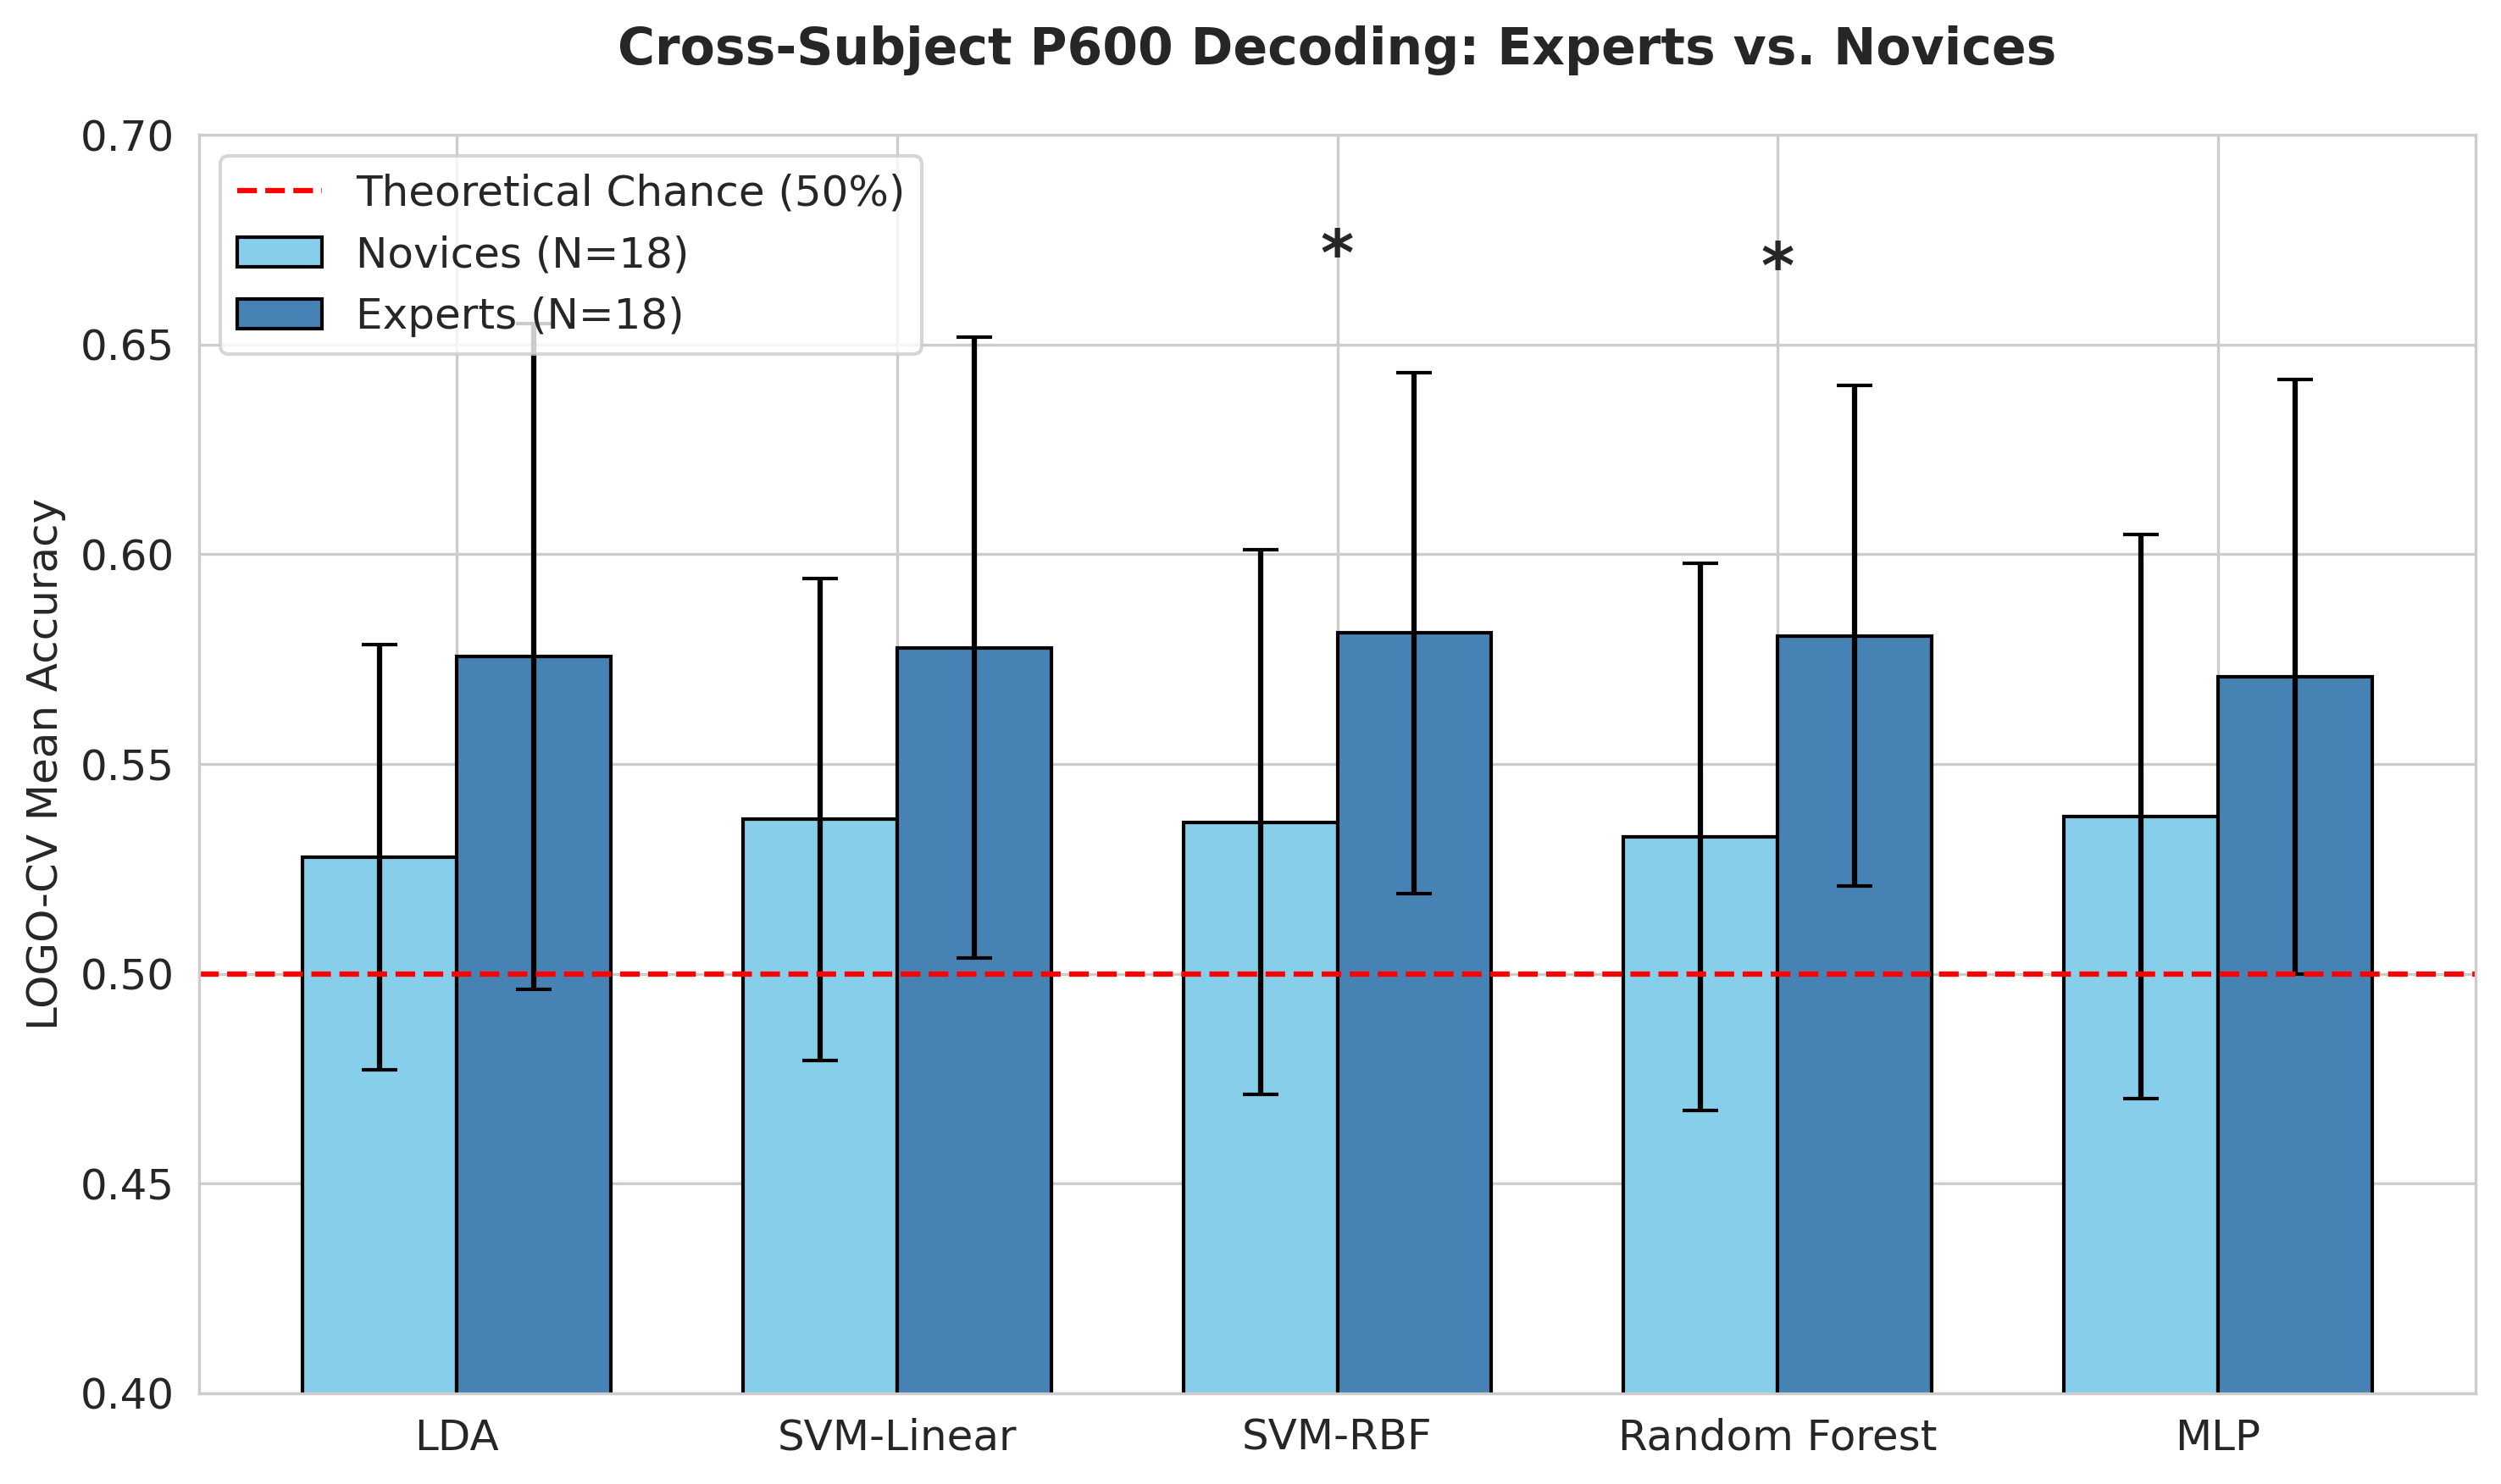

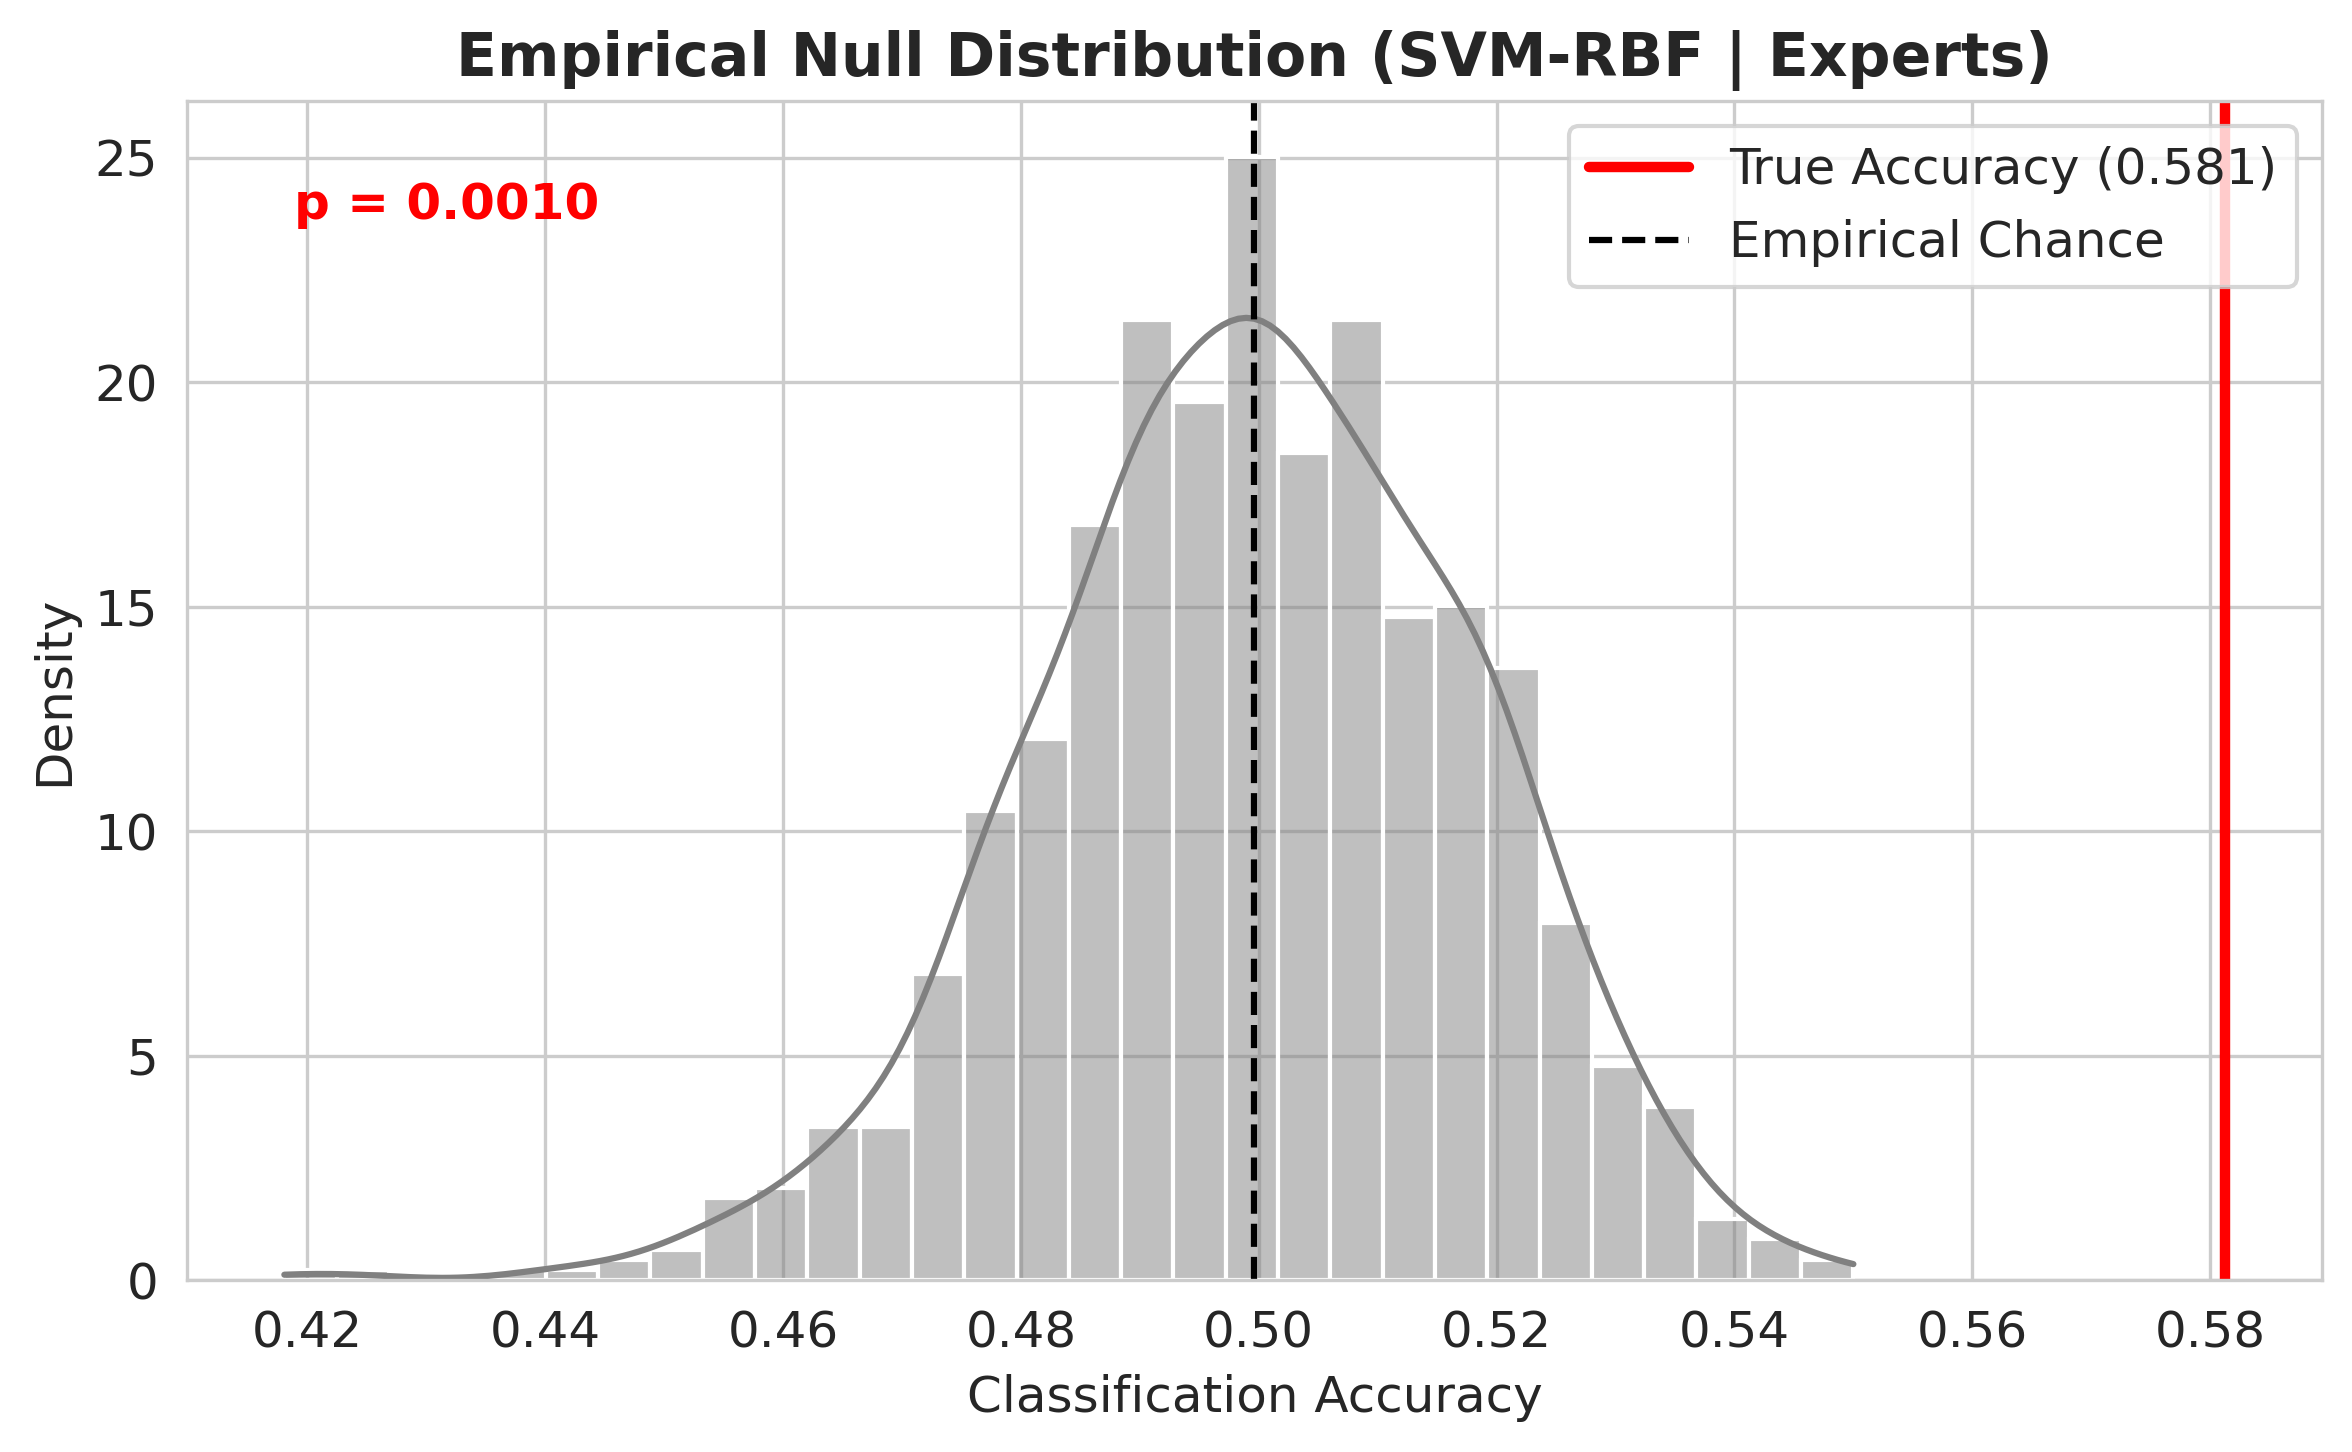

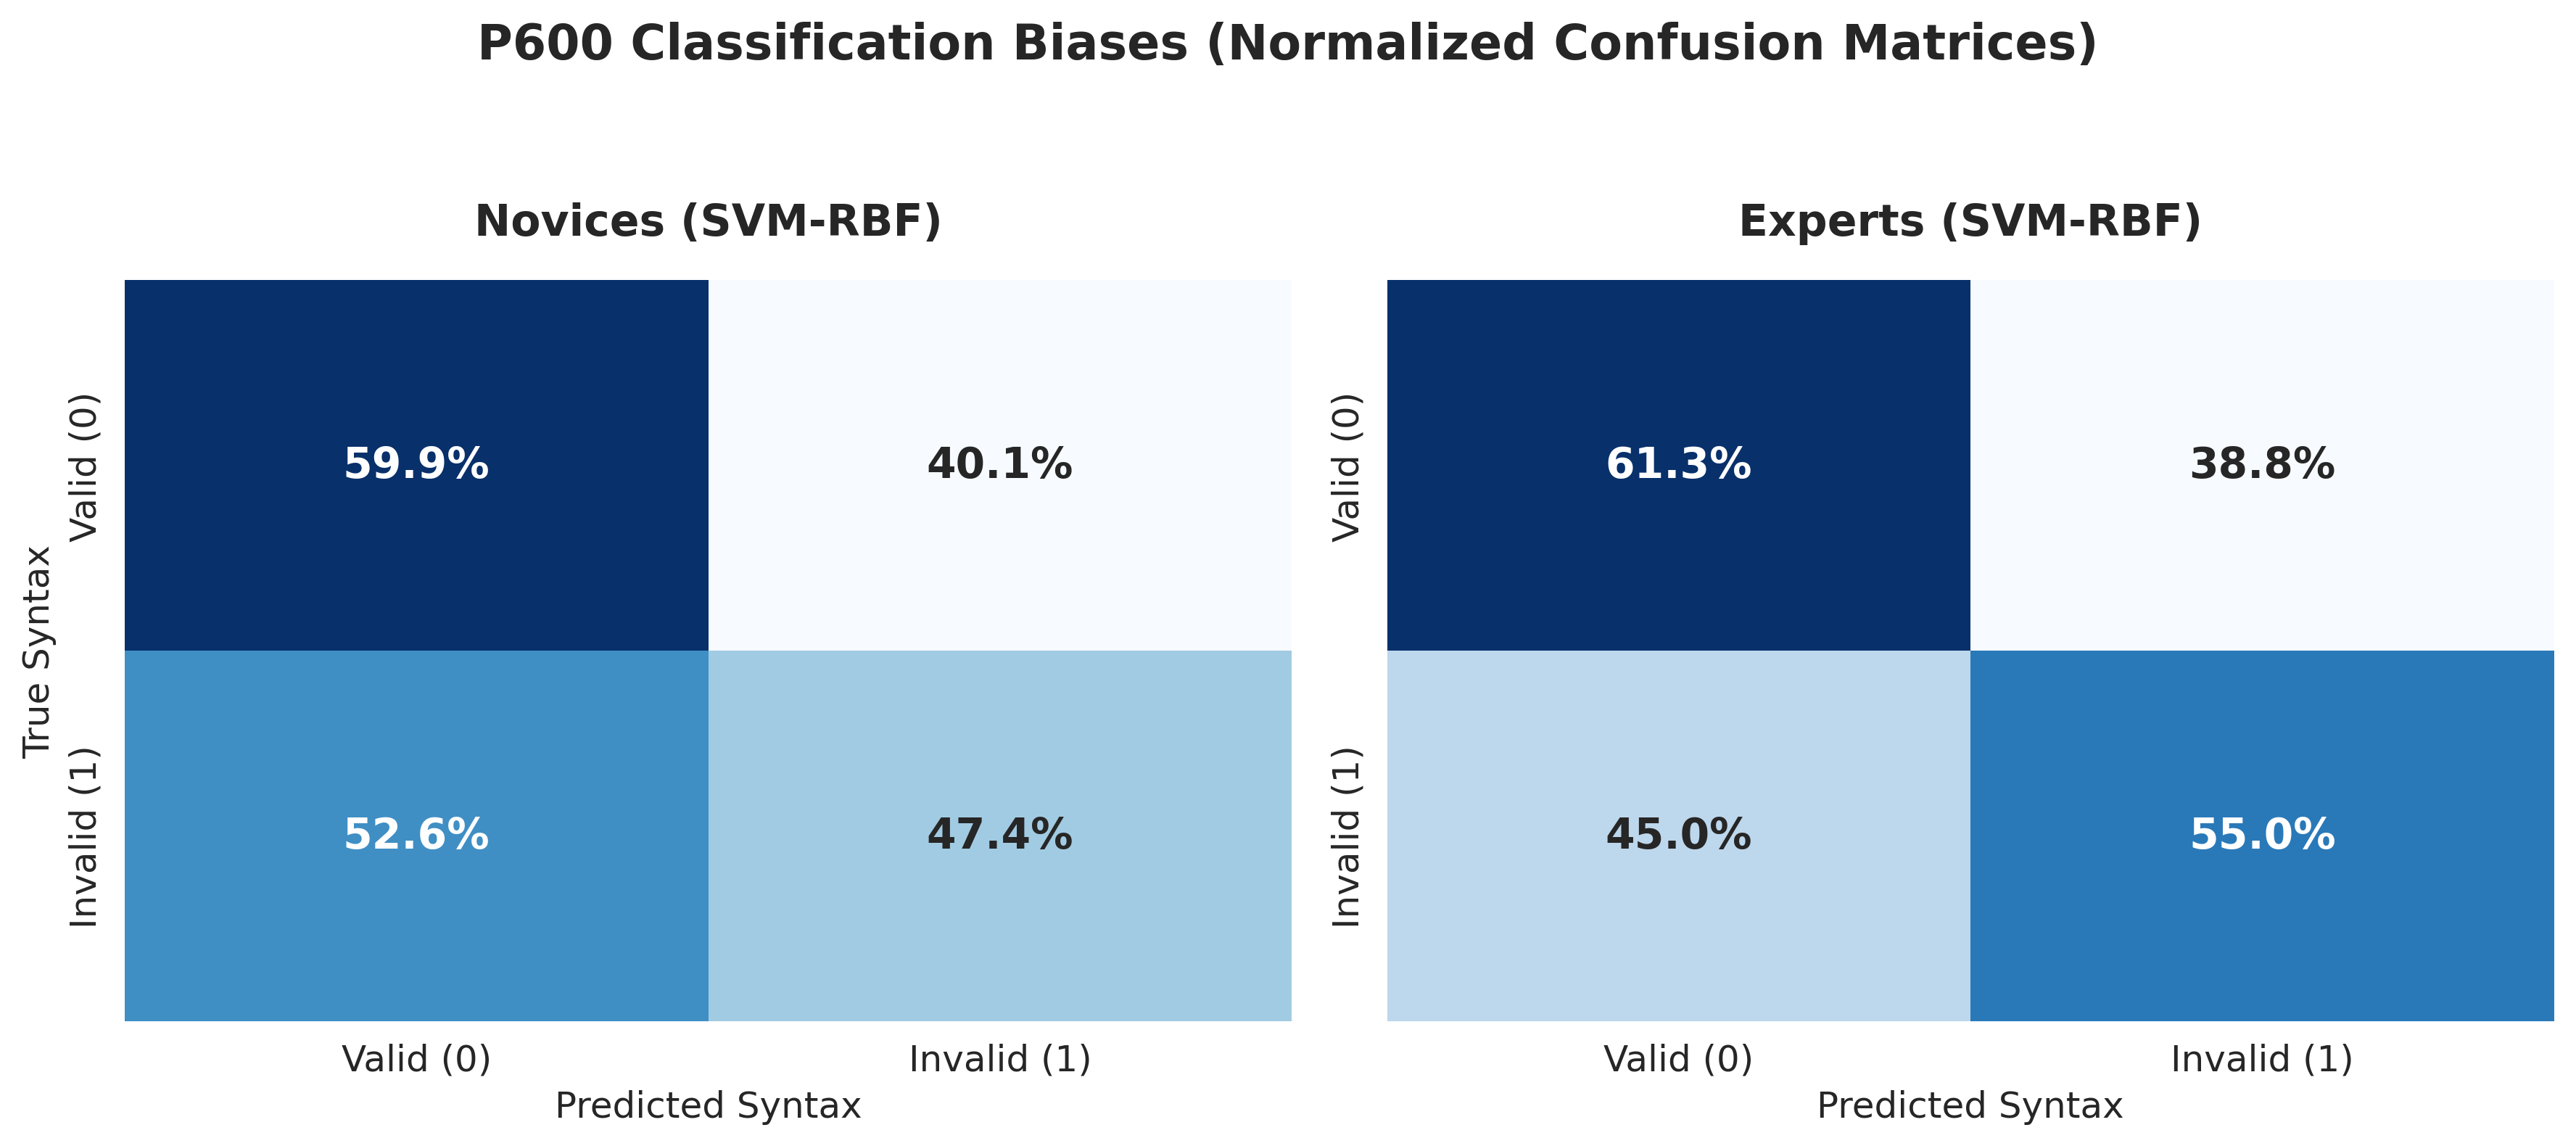


--- VISUALIZATION COMPLETE ---
figures exported to: /content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/Figures


In [16]:
# VISUALIZATIONS
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

print("\n--- INITIATING STEP 5: VISUALIZATION ENGINE ---")

# deifning paths and loading the data
BASE_DIR = "/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding"
EXPORT_DIR = os.path.join(BASE_DIR, "export_data")
FIG_DIR = os.path.join(BASE_DIR, "Figures")
os.makedirs(FIG_DIR, exist_ok=True)

PKL_PATH = os.path.join(EXPORT_DIR, "Master_Export_Metrics.pkl")

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

# FIGURE 1 - plotting models for a comparative analysis (EXPERT VS NOVICE)
models = ['LDA', 'SVM-Linear', 'SVM-RBF', 'Random Forest', 'MLP']
novice_accs = [data['Novices'][m]['mean_accuracy'] for m in models]
novice_stds = [data['Novices'][m]['std_accuracy'] for m in models]
expert_accs = [data['Experts'][m]['mean_accuracy'] for m in models]
expert_stds = [data['Experts'][m]['std_accuracy'] for m in models]

# GLOBAL STYLE
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
sns.set_style("whitegrid")

# DECODING PERFORMANCE
fig1, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
x = np.arange(len(models))
width = 0.35

rects1 = ax1.bar(x - width/2, novice_accs, width, yerr=novice_stds, label='Novices (N=18)', color='#87CEEB', edgecolor='black', capsize=5)
rects2 = ax1.bar(x + width/2, expert_accs, width, yerr=expert_stds, label='Experts (N=18)', color='#4682B4', edgecolor='black', capsize=5)

ax1.axhline(0.50, color='red', linestyle='--', linewidth=1.5, label='Theoretical Chance (50%)')
ax1.set_ylabel('LOGO-CV Mean Accuracy')
ax1.set_title('Cross-Subject P600 Decoding: Experts vs. Novices', fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0.40, 0.70)
ax1.legend(loc='upper left')

# statistical annotation (Mann-Whitney U on CV folds)
for i, m in enumerate(models):
    stat, p = mannwhitneyu(data['Novices'][m]['cv_scores'], data['Experts'][m]['cv_scores'], alternative='less')
    if p < 0.05:
        ax1.text(x[i], max(novice_accs[i] + novice_stds[i], expert_accs[i] + expert_stds[i]) + 0.02,
                 '*', ha='center', va='bottom', fontsize=18, fontweight='bold')

fig1.tight_layout()
fig1_path = os.path.join(FIG_DIR, "Fig1_Accuracy_Comparison.png")
fig1.savefig(fig1_path)
plt.show()

# FIGURE 2 - Empirical Null Distribution
target_model = 'SVM-RBF'
target_cohort = 'Experts'
perm_scores = data[target_cohort][target_model]['perm_scores']
true_score = data[target_cohort][target_model]['mean_accuracy']
p_val = data[target_cohort][target_model]['p_value']

fig2, ax2 = plt.subplots(figsize=(8, 5), dpi=300)
sns.histplot(perm_scores, bins=30, kde=True, color='gray', ax=ax2, stat='density')
ax2.axvline(true_score, color='red', linestyle='-', linewidth=2.5, label=f'True Accuracy ({true_score:.3f})')
ax2.axvline(np.mean(perm_scores), color='black', linestyle='--', linewidth=1.5, label='Empirical Chance')

ax2.set_xlabel("Classification Accuracy")
ax2.set_ylabel("Density")
ax2.set_title(f"Empirical Null Distribution ({target_model} | {target_cohort})", fontweight='bold')
ax2.legend(loc='upper right')
ax2.text(0.05, 0.90, f"p = {p_val:.4f}", transform=ax2.transAxes, fontweight='bold', color='red', fontsize=12)

fig2.tight_layout()
fig2_path = os.path.join(FIG_DIR, "Fig2_Permutation_Histogram.png")
fig2.savefig(fig2_path)
plt.show()

# FIGURE 3: CONFUSION MATRICES FOR SVM RBF
fig3, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
cohorts_to_plot = ['Novices', 'Experts']

for i, cohort in enumerate(cohorts_to_plot):
    cm = data[cohort]['SVM-RBF']['confusion_matrix']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", cbar=False,
                xticklabels=['Valid (0)', 'Invalid (1)'],
                yticklabels=['Valid (0)', 'Invalid (1)'], ax=axes[i],
                annot_kws={"size": 14, "weight": "bold"})

    axes[i].set_title(f'{cohort} (SVM-RBF)', fontweight='bold', pad=15)
    axes[i].set_xlabel('Predicted Syntax')
    if i == 0:
        axes[i].set_ylabel('True Syntax')

fig3.suptitle("P600 Classification Biases (Normalized Confusion Matrices)", fontsize=16, fontweight='bold', y=1.05)
fig3.tight_layout()
fig3_path = os.path.join(FIG_DIR, "Fig3_Confusion_Matrices.png")
fig3.savefig(fig3_path)
plt.show()

print("\n--- VISUALIZATION COMPLETE ---")
print(f"figures exported to: {FIG_DIR}")

## 7. Additional Data Export (EXTRACTING ROC SCORES AND SUBJECT MAPS)

In [17]:
# ROC SCORE + SUBJECT ID MAP
import os
import pickle
from sklearn.model_selection import cross_val_predict

print("\n--- INITIATING ROC + SUBJECT ID EXTRACTION ---")

EXPORT_DIR = "/content/drive/MyDrive/EEG_data/2505_inter-subject_decoding/export_data"
pkl_path = os.path.join(EXPORT_DIR, "Master_Export_Metrics.pkl")

# loading the master file dir
if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        master_dict = pickle.load(f)
    print("Successfully loaded Master_Export_Metrics.pkl from Drive.")
else:
    raise FileNotFoundError("CRITICAL ERROR: Master PKL not found. Run Chunk 8 first.")

# iterating and extracting the continuous scores and subject IDs
for cohort, (X_data, y_data, groups_data) in tuning_cohorts.items():
    print(f"\nProcessing Extractions for: {cohort}...")

    if cohort not in master_dict:
        continue

    for model_name, best_estimator in best_estimators_dict[cohort].items():
        if model_name not in master_dict[cohort]:
            continue

        print(f"  -> Extracting continuous scores for {model_name}...")

        # checking if the model supports true probabilities
        clf = best_estimator.steps[-1][1]

        if hasattr(clf, "predict_proba"):
            # extracting the probability of a positive class
            y_prob_full = cross_val_predict(best_estimator, X_data, y_data, groups=groups_data, cv=logo_grid, n_jobs=-1, method='predict_proba')
            y_score = y_prob_full[:, 1]
        else:
            # DECISION FUNCTION FOR THE SVM
            y_score = cross_val_predict(best_estimator, X_data, y_data, groups=groups_data, cv=logo_grid, n_jobs=-1, method='decision_function')

        # appending the new arrays to the existing dicts
        master_dict[cohort][model_name]['y_score'] = y_score
        master_dict[cohort][model_name]['subject_ids'] = groups_data

# saving to gdrive
with open(pkl_path, 'wb') as f:
    pickle.dump(master_dict, f)

print("\n--- ROC & SUBJECT ID APPEND COMPLETE ---")


--- INITIATING ROC + SUBJECT ID EXTRACTION ---
Successfully loaded Master_Export_Metrics.pkl from Drive.

Processing Extractions for: Global...
  -> Extracting continuous scores for LDA...
  -> Extracting continuous scores for SVM-Linear...
  -> Extracting continuous scores for SVM-RBF...
  -> Extracting continuous scores for Random Forest...
  -> Extracting continuous scores for MLP...

Processing Extractions for: Novices...
  -> Extracting continuous scores for LDA...
  -> Extracting continuous scores for SVM-Linear...
  -> Extracting continuous scores for SVM-RBF...
  -> Extracting continuous scores for Random Forest...
  -> Extracting continuous scores for MLP...

Processing Extractions for: Experts...
  -> Extracting continuous scores for LDA...
  -> Extracting continuous scores for SVM-Linear...
  -> Extracting continuous scores for SVM-RBF...
  -> Extracting continuous scores for Random Forest...
  -> Extracting continuous scores for MLP...

--- ROC & SUBJECT ID APPEND COMPLETE